# PC3236 $\cdot$ Computational Methods in Physics
### Parth Bhargava $\cdot$ A0310667E
## Assignment 1



### Problem 1: Finite square well
We solve the 1-D time-independent Schrodinger equation for a finite square well of total width `2a = 8 Angstrom` (so `a = 4 Angstrom`), barrier height `V0 = 8 eV`, and mass `m = 10 me`.

Model (as in the assignment figure, with the well bottom at 0):
- `V(x) = 0` for `|x| <= a`
- `V(x) = V0` for `|x| > a`

### Equations to solve
We solve the 1D time-independent Schrodinger equation,

`-(hbar^2 / (2m)) d^2 psi / dx^2 + V(x) psi = E psi`,

with the finite square well potential. Imposing continuity of `psi` and `dpsi/dx` at `x = +-a` gives the bound-state conditions:

- even: `k tan(k a) = kappa`
- odd: `-k cot(k a) = kappa`

### Numerical method
We solve the even/odd transcendental equations with bisection. To choose brackets, note that the functions involve `tan(ka)` or `cot(ka)`, which have known asymptotes:

- `tan(ka)` has its first asymptote at `ka = pi/2`.
- `cot(ka)` has its first non-zero asymptote at `ka = pi`.

We therefore search for the lowest even root in `(0, pi/(2a))` and the lowest odd root in `(0, pi/a)`. In energy terms this corresponds to the first interval below the `tan`/`cot` asymptotes, ensuring exactly one root in each bracket and stable convergence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.054571817e-34  # J s
me = 9.1093837015e-31   # kg
eV = 1.602176634e-19    # J
angstrom = 1.0e-10      # m

m = 10.0 * me
V0 = 8.0 * eV
a = 4.0 * angstrom

k0 = np.sqrt(2.0 * m * V0) / hbar

In [3]:
def f_even(k):
    if k <= 0 or k >= k0:
        return np.nan
    kappa = np.sqrt(k0**2 - k**2)
    return k * np.tan(k * a) - kappa


def f_odd(k):
    if k <= 0 or k >= k0:
        return np.nan
    kappa = np.sqrt(k0**2 - k**2)
    return -k / np.tan(k * a) - kappa


def bisect_root(f, lo, hi, tol=1e-12, max_iter=200):
    flo = f(lo)
    fhi = f(hi)
    if not np.isfinite(flo) or not np.isfinite(fhi) or flo * fhi > 0:
        return None
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = f(mid)
        if not np.isfinite(fmid):
            return None
        if abs(fmid) < tol:
            return mid
        if flo * fmid <= 0:
            hi = mid
            fhi = fmid
        else:
            lo = mid
            flo = fmid
    return 0.5 * (lo + hi)


def find_roots(f, k_min, k_max, n=20000):
    ks = np.linspace(k_min, k_max, n)
    roots = []
    f_prev = f(ks[0])
    for i in range(1, len(ks)):
        k = ks[i]
        f_cur = f(k)
        if not np.isfinite(f_prev) or not np.isfinite(f_cur):
            f_prev = f_cur
            continue
        if f_prev * f_cur < 0:
            root = bisect_root(f, ks[i - 1], k)
            if root is not None:
                roots.append(root)
        f_prev = f_cur
    return roots


roots_even = find_roots(f_even, 1e-9, k0 - 1e-9)
roots_odd = find_roots(f_odd, 1e-9, k0 - 1e-9)

k_even = roots_even[0]
k_odd = roots_odd[0]

E_even = (hbar**2 * k_even**2) / (2.0 * m)
E_odd = (hbar**2 * k_odd**2) / (2.0 * m)

print(f"Lowest even state: E = {E_even / eV:.6f} eV")
print(f"Lowest odd state:  E = {E_odd / eV:.6f} eV")

Lowest even state: E = 0.052827 eV
Lowest odd state:  E = 0.211233 eV


### Final answers (Q1)
- Lowest even state energy: `E = 0.052827 eV`
- Lowest odd state energy: `E = 0.211233 eV`

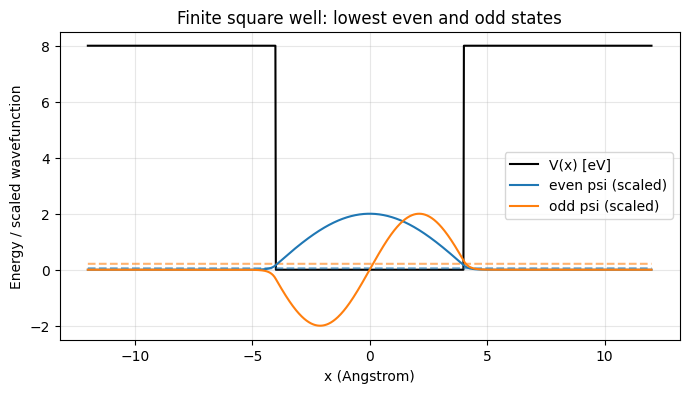

In [4]:
def psi_even(x):
    k = k_even
    kappa = np.sqrt(k0**2 - k**2)
    inside = np.cos(k * x)
    outside = np.cos(k * a) * np.exp(-kappa * (np.abs(x) - a))
    return np.where(np.abs(x) <= a, inside, outside)


def psi_odd(x):
    k = k_odd
    kappa = np.sqrt(k0**2 - k**2)
    inside = np.sin(k * x)
    outside = np.sign(x) * np.sin(k * a) * np.exp(-kappa * (np.abs(x) - a))
    return np.where(np.abs(x) <= a, inside, outside)


x = np.linspace(-3 * a, 3 * a, 1200)
V = np.where(np.abs(x) <= a, 0.0, V0) / eV

scale = 2.0
plt.figure(figsize=(8, 4))
plt.plot(x / angstrom, V, color="black", label="V(x) [eV]")
plt.plot(x / angstrom, E_even / eV * np.ones_like(x), "--", color="tab:blue", alpha=0.6)
plt.plot(x / angstrom, E_odd / eV * np.ones_like(x), "--", color="tab:orange", alpha=0.6)
plt.plot(x / angstrom, scale * psi_even(x), color="tab:blue", label="even psi (scaled)")
plt.plot(x / angstrom, scale * psi_odd(x), color="tab:orange", label="odd psi (scaled)")
plt.xlabel("x (Angstrom)")
plt.ylabel("Energy / scaled wavefunction")
plt.title("Finite square well: lowest even and odd states")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Short discussion
The computed energies lie strictly between `0` and `V0`, as expected for bound states in a finite well. The plotted even/odd wavefunctions have the correct parity and show exponential decay outside the well. The wavefunctions are shown with an arbitrary scale (normalization not required).

### Problem 2: Satellite orbit
Given

`R = C / (1 + e sin(theta + alpha))`

and three observations, solve for `C`, `e`, and `alpha` numerically. Following the course notes, we use the Newton-Raphson method for a system of three nonlinear equations with a finite-difference Jacobian, then compute the minimum value of `R` and the corresponding angle.

### Initial guess for Newton-Raphson
We use `C0` near the average radius, `e0` based on the relative spread of the observed radii, and `alpha0 = 0` as a neutral phase. These are physically reasonable and keep the nonlinear solve well-behaved:

- `C0 = (R_max + R_min)/2`
- `e0 = (R_max - R_min)/(R_max + R_min)`
- `alpha0 = 0`

In [5]:
theta_deg = np.array([-30.0, 0.0, 30.0])
R = np.array([6870.0, 6728.0, 6615.0])  # km

theta = np.deg2rad(theta_deg)


def residual(params):
    C, e, alpha = params
    return np.array([C / (1.0 + e * np.sin(t + alpha)) - Ri for t, Ri in zip(theta, R)])


def jacobian_fd(func, x, base_h=1e-6):
    f0 = func(x)
    n = len(x)
    J = np.zeros((n, n))
    for i in range(n):
        dx = base_h * max(1.0, abs(x[i]))
        x1 = x.copy()
        x1[i] += dx
        f1 = func(x1)
        J[:, i] = (f1 - f0) / dx
    return J, f0


def newton_system(x0, tol=1e-10, max_iter=50):
    x = x0.copy()
    for i in range(max_iter):
        J, f0 = jacobian_fd(residual, x)
        if np.linalg.norm(f0) / np.sqrt(len(x)) < tol:
            return x, i + 1
        dx = np.linalg.solve(J, -f0)
        x = x + dx
        if np.linalg.norm(dx) / np.sqrt(len(x)) < tol:
            return x, i + 1
    return x, max_iter


R_max, R_min_obs = np.max(R), np.min(R)
C0 = 0.5 * (R_max + R_min_obs)
e0 = (R_max - R_min_obs) / (R_max + R_min_obs)
alpha0 = 0.0

(C, ecc, alpha), iters = newton_system(np.array([C0, e0, alpha0], dtype=float))

R_min = C / (1.0 + ecc)
theta_min = 0.5 * np.pi - alpha  # radians

theta_min_deg = (np.rad2deg(theta_min) + 180) % 360 - 180

print(f"C = {C:.6f} km")
print(f"eccentricity e = {ecc:.6f}")
print(f"alpha = {np.rad2deg(alpha):.6f} deg")
print(f"Minimum R = {R_min:.6f} km")
print(f"Theta at minimum R = {theta_min_deg:.6f} deg")
print(f"Newton-Raphson iterations: {iters}")

C = 6819.293793 km
eccentricity e = 0.040599
alpha = 19.525485 deg
Minimum R = 6553.239107 km
Theta at minimum R = 70.474515 deg
Newton-Raphson iterations: 7


### Final answers (Q2)
- `C = 6819.293793 km`
- `e = 0.040599`
- `alpha = 19.525485 deg`
- `theta_min = 70.474515 deg`
- `R_min = 6553.239107 km`

### Short discussion
The fitted eccentricity is small (`e << 1`), indicating a nearly circular orbit, which matches the modest variation in the measured radii. The minimizing angle follows directly from the maximum of `sin(theta + alpha)`.